In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov







/tmp/ipykernel_3246722/1104681880.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# df = pk.load(open(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))




In [3]:
samps = []
keys = []
for key in df:
    # if ('base' not in key) and ('decentered' not in key):
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
        if key not in ['RUN_SETTINGS', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestfit = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]



(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
A_IA 0.21730561725829953
A_IA_base 0.2607667407099594
Delta_z_bias_array_0 -0.0015197448326600205
Delta_z_bias_array_1 -0.010565830291428319
Delta_z_bias_array_2 -0.00909136222753839
Delta_z_bias_array_3 0.005929553969403655
Delta_z_bias_array_decentered_0 -0.08443026848111226
Delta_z_bias_array_decentered_1 -0.7043886860952213
Delta_z_bias_array_decentered_2 -0.8264874752307627
Delta_z_bias_array_decentered_3 0.34879729231786205
Ob0 0.04782411664573842
Ob0_base -0.32638250313923667
Om0 0.2660117251647165
Om0_base -0.509824122529253
alpha_ky 0.941538160131925
alpha_ky_base -0.8769275980211249
alpha_nt 0.3608349459292174
alpha_nt_base 1.330019351150609
eta_IA 1.1469704086232486
eta_IA_base 1.1469704086232486
h 0.7011301124624106
h_base 0.01695168693616056
mu_beta 0.5294355866617271
mu_beta_base -1.0161286069169913
mult_shear_bias

In [4]:
# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


for key in saved_bestfit.keys():
    if key in list(sim_params_dict.keys()):
        sim_params_dict[key] = float(saved_bestfit[key])
    if key in list(sim_params_dict['cosmo'].keys()):
        sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
        if key == 'h':
            sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
    if key in list(other_params_dict.keys()):
        other_params_dict[key] = float(saved_bestfit[key])
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']




In [5]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



In [6]:
deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}
deproj = 'cib_1p7_dBeta'
probe = 'all'
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
bin1_all = df_measure['bin1_all']
bin2_all = df_measure['bin2_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)



In [7]:
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]



cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']



def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)







In [8]:
def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_all = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_all = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_all = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))



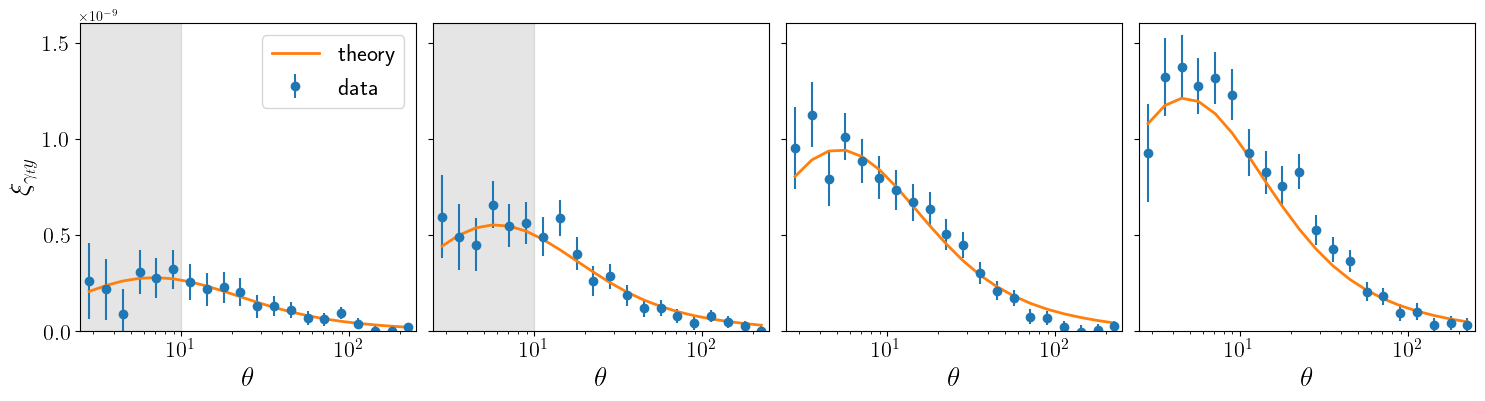

In [10]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='theory', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.6e-9)
    ax.set_xlabel(r'$\theta$', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
fig.savefig(sdir + 'gty_dv_v10.pdf', bbox_inches='tight', dpi=300)
pl.show()



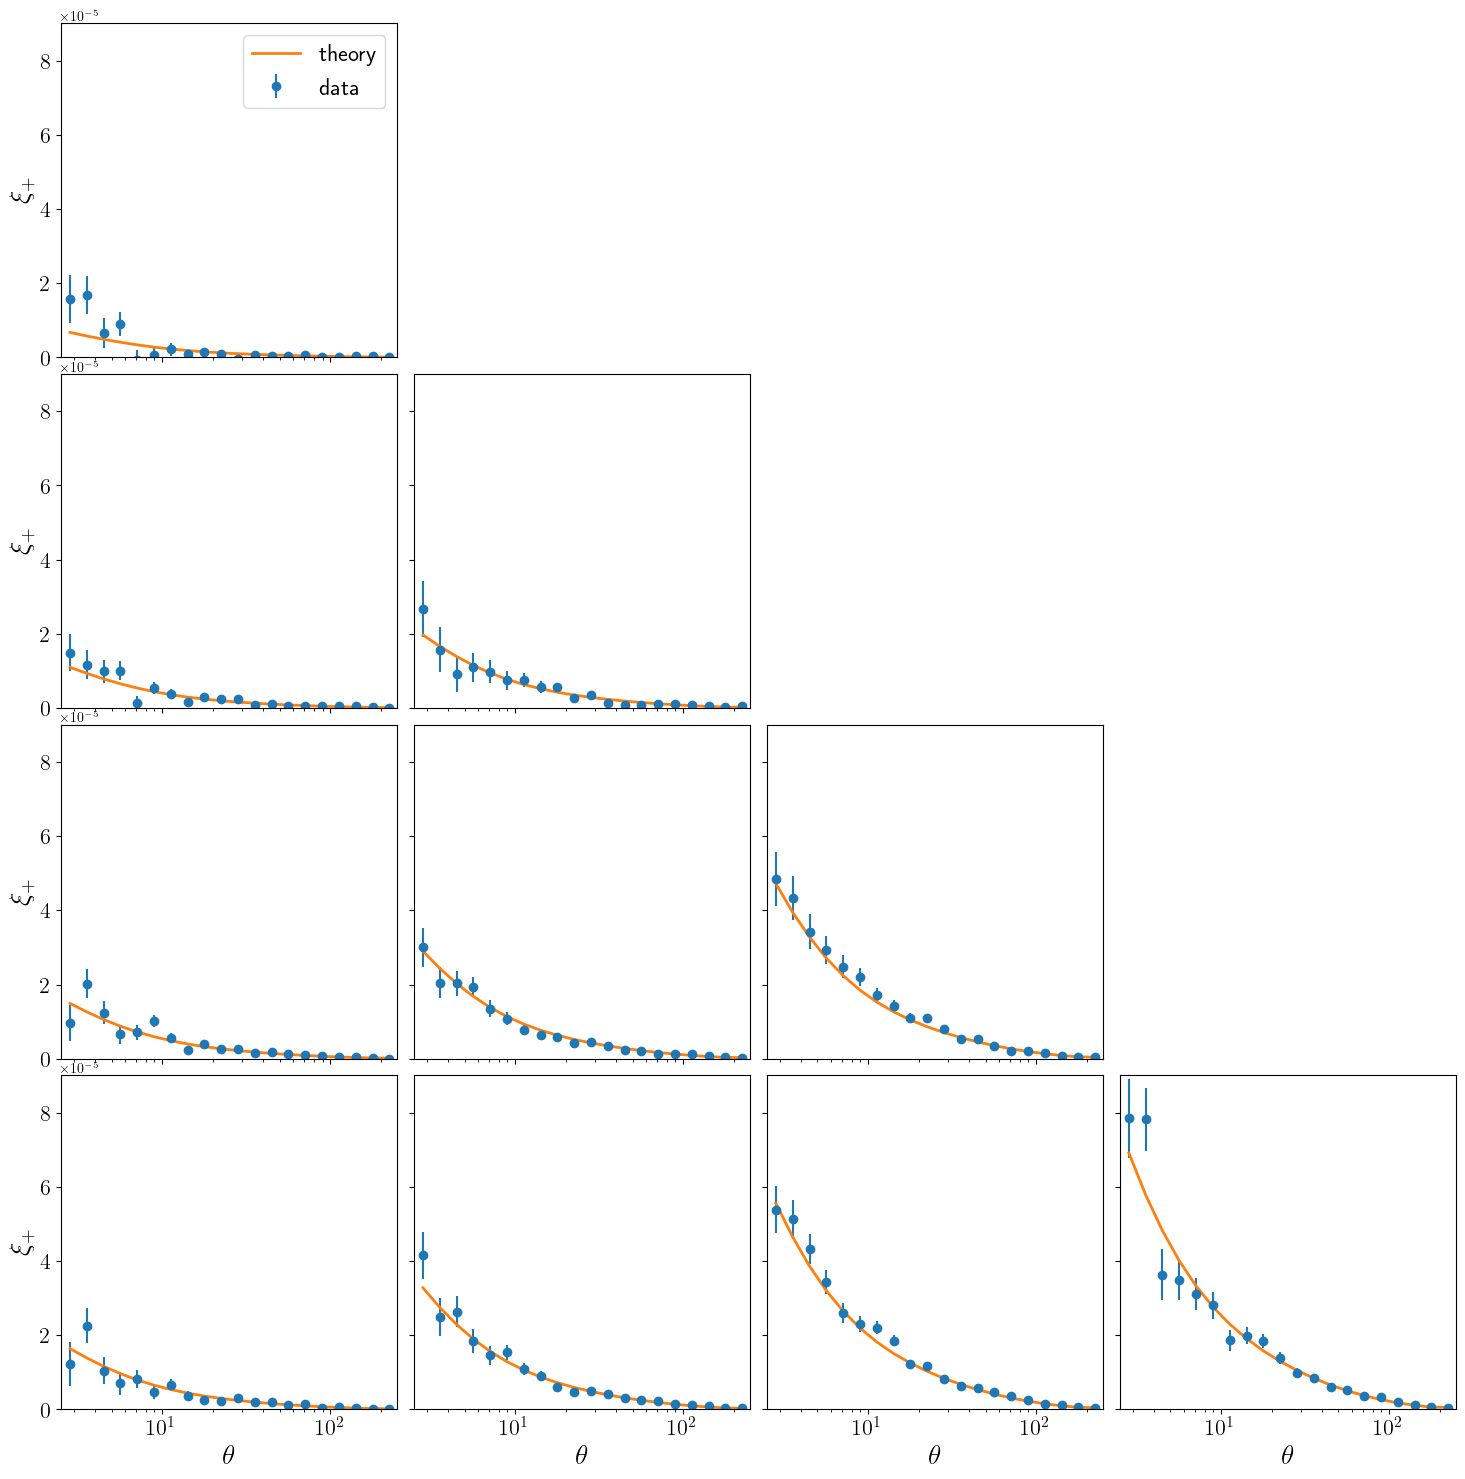

In [11]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='theory', lw=2)
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
fig.savefig(sdir + 'xip_dv_v10.pdf', bbox_inches='tight', dpi=300)
pl.show()



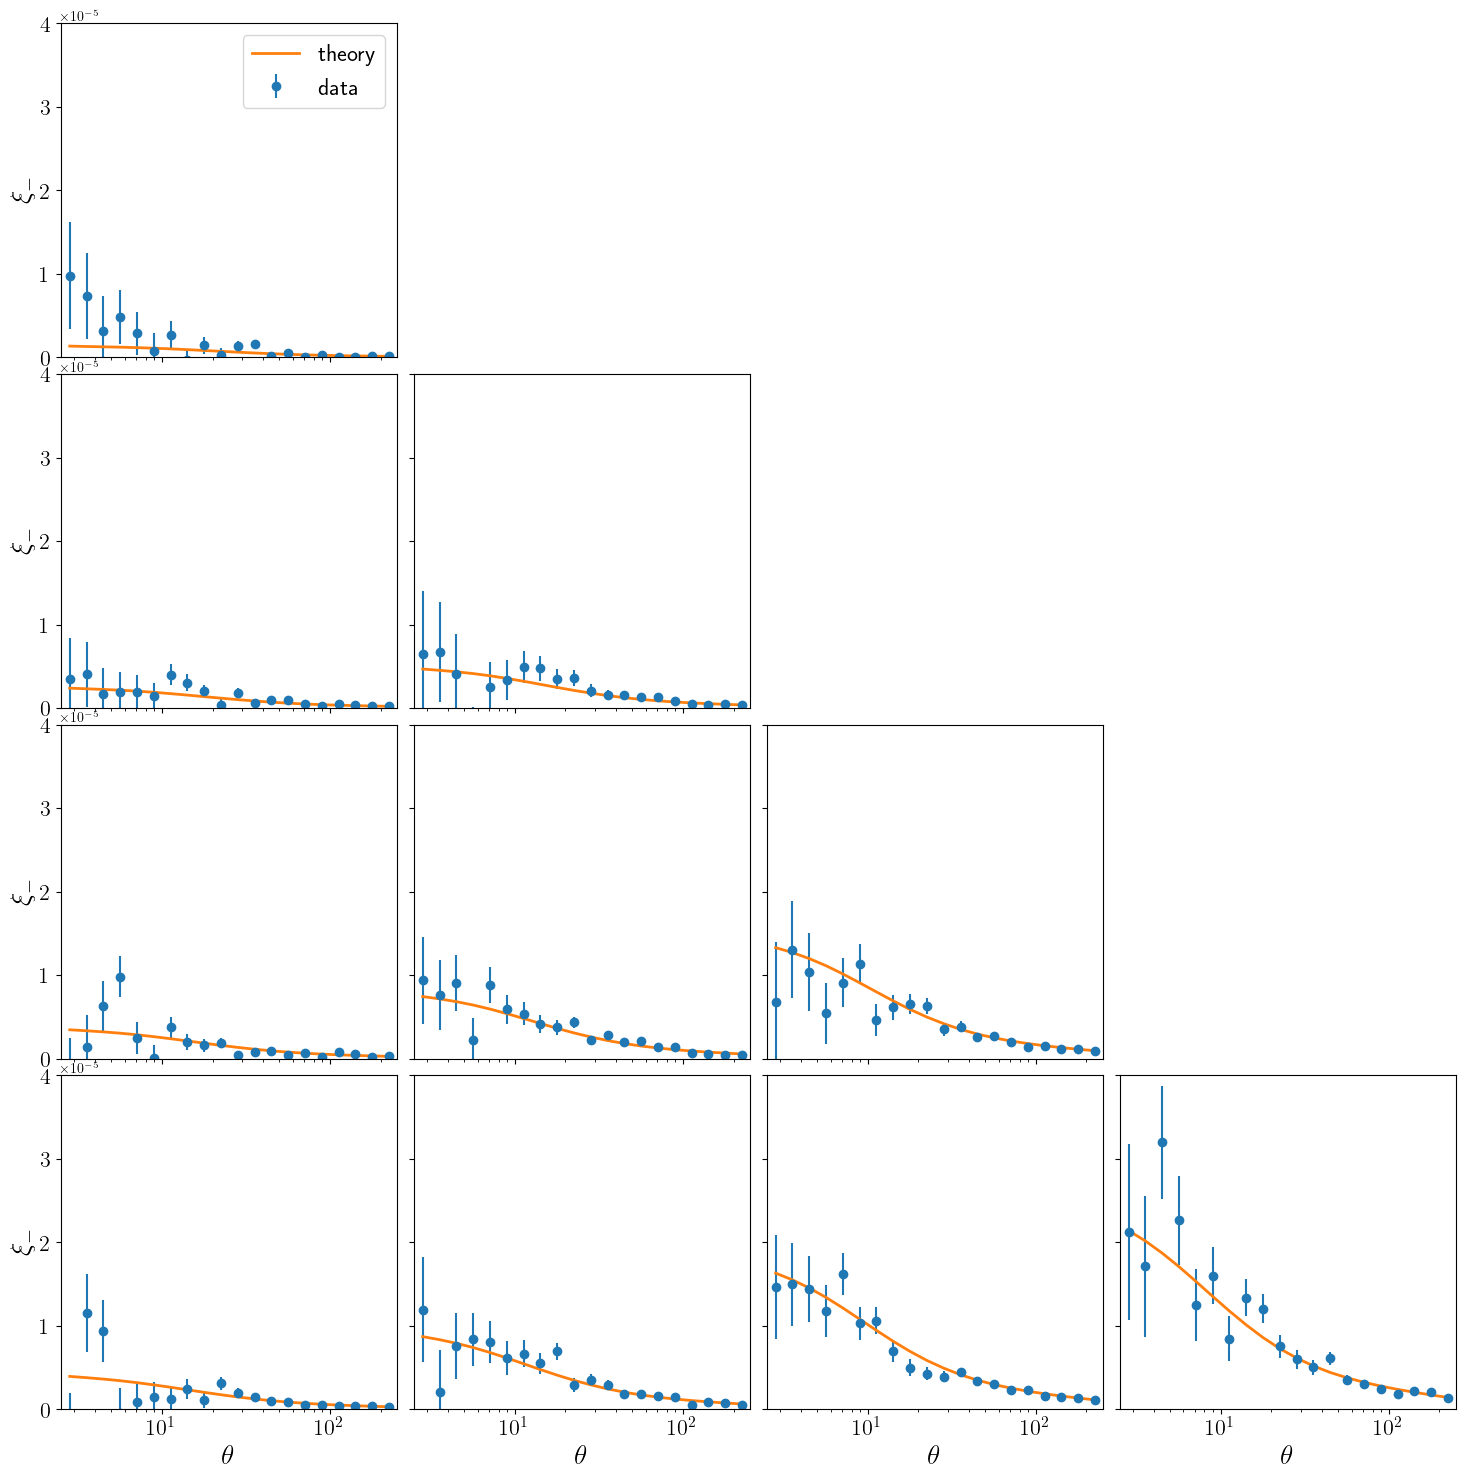

In [12]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='theory', lw=2)
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# pl.yscale('log')
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xim_dv.png', bbox_inches='tight', dpi=300)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
fig.savefig(sdir + 'xim_dv_v10.pdf', bbox_inches='tight', dpi=300)
pl.show()






In [9]:
from astropy.io import fits
deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}


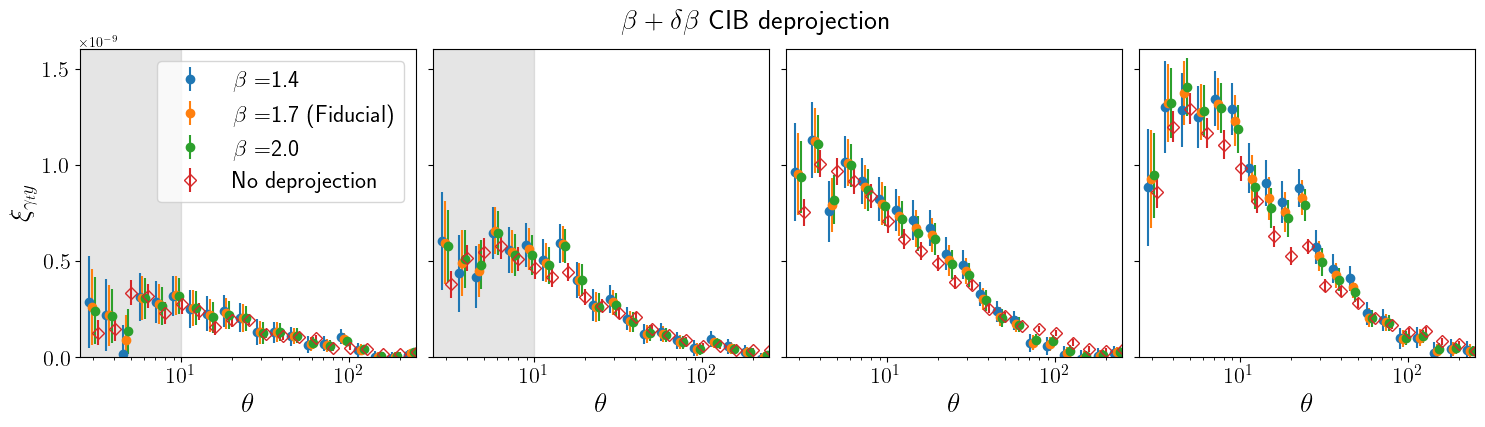

In [15]:
deproj_list = ['cib_1p4_dBeta','cib_1p7_dBeta','cib_2p0_dBeta', 'None']
# beta_vals = [1.4, 1.7, 2.0]
beta_vals = [1.4, 1.7, 2.0, 'None']
gty_list = {}
for deproj in deproj_list:
    probe = 'all'
    save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
    df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
    cov_total = df_measure['cov_total']
    xi_all = df_measure['xi_all']
    theta_all = df_measure['theta_all']
    bin1_all = df_measure['bin1_all']
    bin2_all = df_measure['bin2_all']
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
    df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
    cov_total = df_measure['cov_total']
    xi_all = df_measure['xi_all']
    theta_all = df_measure['theta_all']
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
    bin1_vals =  df_cs['xip'].data['BIN1'][::20]
    bin2_vals =  df_cs['xip'].data['BIN2'][::20]
    biny_vals = np.array([1,2,3,4])
    ang_vals = df_cs['xip'].data['ANG'][0:20]
    
    
    
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    
    gty_dv = data_vec[:80]
    sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]
    
    gty_list[deproj] = [gty_dv,sig_gty_dv]
    

# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    for jp, deproj in enumerate(deproj_list):
        gty_dv, sig_gty_dv = gty_list[deproj]
        if beta_vals[jp] == 1.7:
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]) + ' (Fiducial)', ls='', marker='o')
        elif beta_vals[jp] == 'None':
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'No deprojection', ls='', marker='D', fillstyle='none')            
        else:
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]), ls='', marker='o')
    # ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='theory', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.6e-9)
    ax.set_xlabel(r'$\theta$', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
pl.suptitle(r'$\beta + \delta \beta $ CIB deprojection', fontsize=20)
# fig.savefig(sdir + 'gty_dv.pdf', bbox_inches='tight', dpi=300)
fig.savefig(sdir + 'gty_dv_beta_dbeta.pdf', bbox_inches='tight', dpi=300)
pl.show()





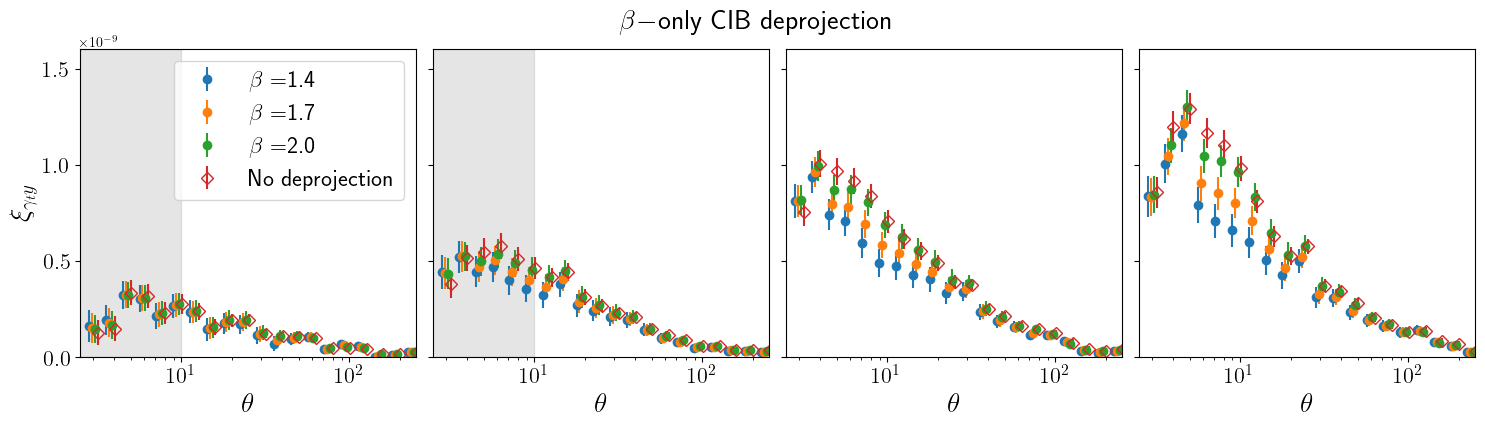

In [16]:
deproj_list = ['cib_1p4','cib_1p7','cib_2p0', 'None']
beta_vals = [1.4, 1.7, 2.0, 'None']
gty_list = {}
for deproj in deproj_list:
    probe = 'all'
    save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
    df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
    cov_total = df_measure['cov_total']
    xi_all = df_measure['xi_all']
    theta_all = df_measure['theta_all']
    bin1_all = df_measure['bin1_all']
    bin2_all = df_measure['bin2_all']
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
    df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
    cov_total = df_measure['cov_total']
    xi_all = df_measure['xi_all']
    theta_all = df_measure['theta_all']
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
    bin1_vals =  df_cs['xip'].data['BIN1'][::20]
    bin2_vals =  df_cs['xip'].data['BIN2'][::20]
    biny_vals = np.array([1,2,3,4])
    ang_vals = df_cs['xip'].data['ANG'][0:20]
    
    
    
    cov_total = jnp.array(cov_total)
    data_vec = jnp.array(xi_all)
    
    
    gty_dv = data_vec[:80]
    sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]
    
    gty_list[deproj] = [gty_dv,sig_gty_dv]
    

# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    for jp, deproj in enumerate(deproj_list):
        gty_dv, sig_gty_dv = gty_list[deproj]
        # if beta_vals[jp] == 1.7:
            # ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]) + ' (Fiducial)', ls='', marker='o')
        # else:
        # ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]), ls='', marker='o')
        if beta_vals[jp] == 1.7:
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]), ls='', marker='o')
        elif beta_vals[jp] == 'None':
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'No deprojection', ls='', marker='D', fillstyle='none')            
        else:
            ax.errorbar((1.04**jp)*theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label=r'$\beta=$' + str(beta_vals[jp]), ls='', marker='o')
    
    # ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='theory', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.6e-9)
    ax.set_xlabel(r'$\theta$', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
pl.suptitle(r'$\beta-$only CIB deprojection', fontsize=20)
fig.savefig(sdir + 'gty_dv_beta_only.pdf', bbox_inches='tight', dpi=300)
pl.show()



